# 02 — Data Cleaning & Validation

Goal: produce `df_cleaned.csv` — typed, validated, de-duplicated.

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Brand palette: Green → Yellow → Purple → Red
COLOURS = ['#027B5B', '#F9DC1C', '#54008B', '#D20F2D']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

DATA_PATH = Path('../Data/match_data.csv')
OUT_PATH  = Path('../Outputs/Cleaning')
OUT_PATH.mkdir(parents=True, exist_ok=True)

## 2. Load Raw Data

Load the supplied dataset and inspect its shape and schema before any modifications are made.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (11239, 14)
Columns: ['league_name', 'season', 'date', 'game_week', 'home_team', 'home_id', 'away_team', 'away_id', 'home_goals', 'away_goals', 'home_xg', 'away_xg', 'is_neutral_venue', 'is_crowds']


,league_name,season,date,game_week,home_team,home_id,away_team,away_id,home_goals,away_goals,home_xg,away_xg,is_neutral_venue,is_crowds
0,Championship,2018/2019,2018-08-03Z,1,Reading,25,Derby County,57,1,2,0.92820,0.72310,0,1
1,League One,2018/2019,2018-08-04Z,1,Sunderland,6,Charlton Athletic,81,2,1,NaN,NaN,0,1
2,Championship,2018/2019,2018-08-04Z,1,Birmingham City,38,Norwich City,20,2,2,1.30576,1.79621,0,1
3,Championship,2018/2019,2018-08-04Z,1,Brentford,72,Rotherham United,71,5,1,2.46905,0.64970,0,1
4,Championship,2018/2019,2018-08-04Z,1,Bristol City,28,Nottingham Forest,39,1,1,0.35720,0.72570,0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11239 entries, 0 to 11238
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   league_name       11239 non-null  str    
 1   season            11239 non-null  str    
 2   date              11239 non-null  str    
 3   game_week         11239 non-null  int64  
 4   home_team         11239 non-null  str    
 5   home_id           11239 non-null  int64  
 6   away_team         11239 non-null  str    
 7   away_id           11239 non-null  int64  
 8   home_goals        11239 non-null  int64  
 9   away_goals        11239 non-null  int64  
 10  home_xg           10686 non-null  float64
 11  away_xg           10683 non-null  float64
 12  is_neutral_venue  11239 non-null  int64  
 13  is_crowds         11239 non-null  int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 1.8 MB


## 3. Column Removal

Three columns are removed before any further processing:

| Column | Reason for removal |
|---|---|
| `is_neutral_venue` | Zero variance — all 11,239 matches are at home grounds (confirmed in EDA) |
| `home_id` | Team name already uniquely identifies the club; numeric ID adds no predictive value |
| `away_id` | Same rationale as `home_id` |

In [4]:
cols_to_drop = ['is_neutral_venue', 'home_id', 'away_id']

shape_before = df.shape
df = df.drop(columns=cols_to_drop)

print(f'Shape before: {shape_before}  →  Shape after: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Shape before: (11239, 14)  →  Shape after: (11239, 11)
Remaining columns: ['league_name', 'season', 'date', 'game_week', 'home_team', 'away_team', 'home_goals', 'away_goals', 'home_xg', 'away_xg', 'is_crowds']


## 4. Date Cleaning

The `date` column arrives with a trailing timezone character (e.g. `2018-08-03Z`). We validate that this is universal, strip the suffix, and convert to a proper `datetime` object.

In [5]:
# Confirm every row has a trailing alphabetic character before we strip it
has_trailing = df['date'].astype(str).str.contains(r'[A-Za-z]$', na=False)
print(f'Rows with trailing letter: {has_trailing.sum():,} / {len(df):,} ({100 * has_trailing.mean():.0f}%)')

assert has_trailing.all(), 'Some dates are missing the expected trailing character — investigate before stripping.'

Rows with trailing letter: 11,239 / 11,239 (100%)


In [6]:
# Strip trailing letter(s) and cast to datetime
df['date'] = pd.to_datetime(df['date'].astype(str).str.replace(r'[A-Za-z]+$', '', regex=True))

# Validate: no nulls introduced, sensible date range
assert df['date'].isna().sum() == 0, 'Null dates found after conversion.'

print(f'Date dtype:  {df["date"].dtype}')
print(f'Date range:  {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Null dates:  {df["date"].isna().sum()}')

Date dtype:  datetime64[us]
Date range:  2018-08-03 → 2026-02-16
Null dates:  0


## 5. Column Renaming

Rename `league_name` to `league` for a cleaner, more concise schema throughout all downstream notebooks.

In [7]:
df = df.rename(columns={'league_name': 'league'})

print(f'Columns: {df.columns.tolist()}')

Columns: ['league', 'season', 'date', 'game_week', 'home_team', 'away_team', 'home_goals', 'away_goals', 'home_xg', 'away_xg', 'is_crowds']


## 6. Whitespace Standardisation

Invisible whitespace differences — leading spaces, trailing spaces, double spaces — can silently create duplicate categories that look identical but are treated as different values by pandas and sklearn encoders. We audit every text column and normalise spacing throughout.

In [8]:
text_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Text columns to audit: {text_cols}')

changes = {}
for col in text_cols:
    before_unique = df[col].nunique()
    # Strip leading/trailing whitespace, then collapse internal multiple spaces
    df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)
    after_unique = df[col].nunique()
    if before_unique != after_unique:
        changes[col] = {'before': before_unique, 'after': after_unique}

if changes:
    print('\nColumns where unique count changed after whitespace clean:')
    for col, counts in changes.items():
        print(f'  {col}: {counts["before"]} → {counts["after"]} unique values')
else:
    print('\nNo changes in unique counts — no hidden whitespace duplicates found.')

# Safety check: whitespace cleaning should only reduce unique counts, never increase them
for col, counts in changes.items():
    assert counts['after'] <= counts['before'], f'Unique count increased in {col} — investigate.'

Text columns to audit: ['league', 'season', 'home_team', 'away_team']

No changes in unique counts — no hidden whitespace duplicates found.


/var/folders/7t/bz9bdmjs5xxb3vbsk7r_l0q80000gn/T/ipykernel_97007/3374388594.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns.tolist()


## 7. Team Name Standardisation

Replace spaces with underscores in all team names to produce a consistent, model-friendly format. This prevents issues with encoders that tokenise on whitespace and ensures team names are handled uniformly throughout feature engineering.

For example: `Preston North End` → `Preston_North_End`

In [9]:
for col in ['home_team', 'away_team']:
    df[col] = df[col].str.replace(' ', '_', regex=False)

# Spot-check a sample of converted names
sample = df['home_team'].unique()[:12]
print('Sample team names after standardisation:')
for name in sorted(sample):
    print(f'  {name}')

Sample team names after standardisation:
  Accrington_Stanley
  Birmingham_City
  Brentford
  Bristol_City
  Ipswich_Town
  Millwall
  Preston_North_End
  Reading
  Sheffield_United
  Sunderland
  West_Bromwich_Albion
  Wigan_Athletic


## 8. Missing xG

Missing xG falls into two cases, handled differently:
- Stray nulls outside League One 2018/19 (a few fixtures): checked against source — the real xG was `0.0`, so filled with `0`.
- League One 2018/19 (552 fixtures): xG was not tracked that season. Left as `NaN` and flagged with `miss_xg`.

        league    season  missing_count
  Championship 2021/2022              1
  Championship 2024/2025              1
    League One 2018/2019            552
    League One 2020/2021              1
    League One 2024/2025              1
Premier League 2018/2019              1


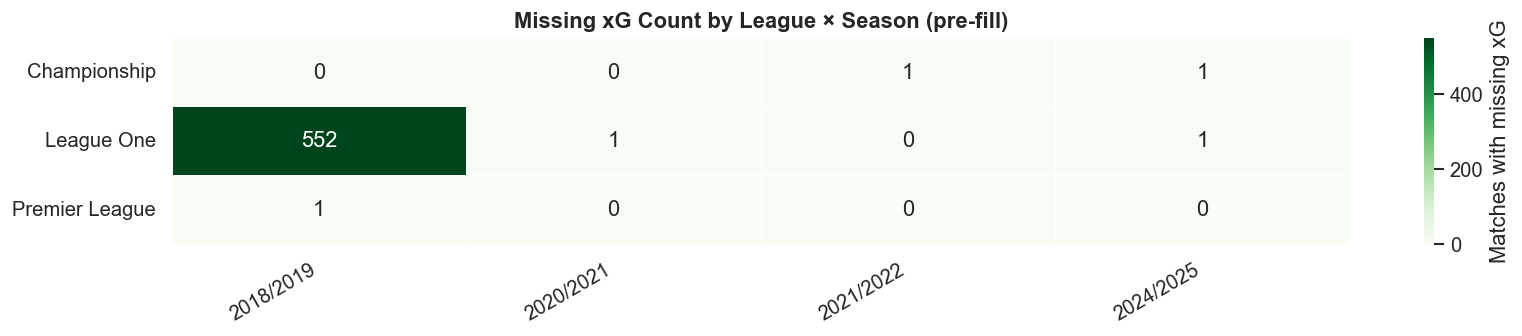

In [10]:
# Use inline null check here — miss_xg doesn't exist yet at this point.
# The same logic (home_xg or away_xg is null) is what miss_xg will encode once created below.
miss_summary = (
    df[df['home_xg'].isna() | df['away_xg'].isna()]
      .groupby(['league', 'season'])
      .size()
      .reset_index(name='missing_count')
)

if miss_summary.empty:
    print('No missing xG rows found.')
else:
    print(miss_summary.to_string(index=False))

    pivot = miss_summary.pivot(index='league', columns='season', values='missing_count').fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(14, 3))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='Greens', linewidths=0.5,
                ax=ax, cbar_kws={'label': 'Matches with missing xG'})
    ax.set_title('Missing xG Count by League × Season (pre-fill)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(OUT_PATH / 'missing_xg_by_league_season.png', bbox_inches='tight')
    plt.show()

### xG Zero-Fill

Fill rule: set `home_xg`/`away_xg` to `0.0` where null, except League One 2018/2019 (preserved as `NaN`).

In [11]:
# Fill NaN xG with 0 for all rows except League One 2018/2019,
# where xG tracking was genuinely absent rather than registering a zero.
fill_mask = ~((df['league'] == 'League One') & (df['season'] == '2018/2019'))

for col in ['home_xg', 'away_xg']:
    null_before = df[col].isna().sum()
    df.loc[fill_mask & df[col].isna(), col] = 0.0
    null_after = df[col].isna().sum()
    print(f'{col}: {null_before} nulls  →  {null_after} nulls after zero-fill')

preserved = df.loc[(df['league'] == 'League One') & (df['season'] == '2018/2019'), 'home_xg'].isna().sum()
print(f'\nLeague One 2018/2019 nulls preserved: {preserved}')

home_xg: 553 nulls  →  552 nulls after zero-fill
away_xg: 556 nulls  →  552 nulls after zero-fill

League One 2018/2019 nulls preserved: 552


In [12]:
# Create binary missingness flag AFTER the zero-fill above.
# Any remaining NaN at this point is a genuine absence of xG tracking (League One 2018/2019).
df['miss_xg'] = (df['home_xg'].isna() | df['away_xg'].isna()).astype(int)

total_missing = df['miss_xg'].sum()
print(f'Rows flagged miss_xg = 1: {total_missing:,} / {len(df):,} ({100 * total_missing / len(df):.1f}%)')
print(f'These should correspond to League One 2018/2019 only.')
print(df[df['miss_xg'] == 1].groupby(['league', 'season']).size().to_string())

Rows flagged miss_xg = 1: 552 / 11,239 (4.9%)
These should correspond to League One 2018/2019 only.
league      season   
League One  2018/2019    552


## 9. Categorical Validation

Inspect all categorical columns for misspellings, inconsistent naming, and unexpected low-frequency values that might indicate data entry errors or duplicate categories under different names.

In [13]:
# League and season: small cardinality — print full distributions
print('=== league ===')
print(df['league'].value_counts().to_string())
print(f'\n=== season ===')
print(df['season'].value_counts().sort_index().to_string())

=== league ===
league
Championship      4243
League One        4076
Premier League    2920

=== season ===
season
2018/2019    1483
2019/2020    1332
2020/2021    1484
2021/2022    1484
2022/2023    1484
2023/2024    1484
2024/2025    1484
2025/2026    1004


In [14]:
# Combine home and away team pools into one frequency count
all_teams = pd.concat([
    df['home_team'].rename('team'),
    df['away_team'].rename('team')
]).value_counts().rename('appearances')

print(f'Total unique teams: {len(all_teams)}')
print(f'\nAll teams sorted alphabetically:')
print(all_teams.sort_index().to_string())

Total unique teams: 87

All teams sorted alphabetically:
team
AFC_Bournemouth            308
AFC_Wimbledon              203
Accrington_Stanley         219
Arsenal                    292
Aston_Villa                300
Barnsley                   350
Birmingham_City            354
Blackburn_Rovers           354
Blackpool                  342
Bolton_Wanderers           295
Bradford_City               76
Brentford                  315
Brighton_&_Hove_Albion     292
Bristol_City               353
Bristol_Rovers             265
Burnley                    308
Burton_Albion              341
Cambridge_United           184
Cardiff_City               345
Carlisle_United             46
Charlton_Athletic          353
Chelsea                    292
Cheltenham_Town            138
Coventry_City              342
Crawley_Town                46
Crewe_Alexandra             92
Crystal_Palace             292
Derby_County               354
Doncaster_Rovers           202
Everton                    292
Exeter_C

In [15]:
# Flag any team appearing fewer than 5 times — potential misspelling or data error
FREQ_THRESHOLD = 5
low_freq = all_teams[all_teams < FREQ_THRESHOLD]

if low_freq.empty:
    print(f'No teams found with fewer than {FREQ_THRESHOLD} appearances — all team names look consistent.')
else:
    print(f'Teams with fewer than {FREQ_THRESHOLD} appearances ({len(low_freq)} found):')
    print(low_freq.to_string())

    # Visualise low-frequency teams
    fig, ax = plt.subplots(figsize=(10, max(3, len(low_freq) * 0.4)))
    low_freq.sort_values().plot.barh(ax=ax, color=COLOURS[2])
    ax.axvline(FREQ_THRESHOLD, color=COLOURS[3], linestyle='--', linewidth=1.2, label=f'Threshold ({FREQ_THRESHOLD})')
    ax.set_title('Low-Frequency Team Names — Possible Errors', fontweight='bold')
    ax.set_xlabel('Total Appearances (home + away)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_PATH / 'low_frequency_teams.png', bbox_inches='tight')
    plt.show()

No teams found with fewer than 5 appearances — all team names look consistent.


## 10. Numeric & Date Validation

Audit all numeric and date-related fields to confirm they are correctly typed, within expected ranges, and free from malformed or anomalous values.

In [16]:
# game_week: expect integers in a sensible range (no English league season exceeds ~50 weeks)
print('=== game_week ===')
print(f'dtype:  {df["game_week"].dtype}')
print(f'Range:  {df["game_week"].min()} → {df["game_week"].max()}')
print(f'Nulls:  {df["game_week"].isna().sum()}')

assert df['game_week'].min() >= 1,  'game_week below 1 found.'
assert df['game_week'].max() <= 60, 'game_week above 60 found — unexpected.'
print('✓ game_week within expected range [1, 60]')

=== game_week ===
dtype:  int64
Range:  1 → 46
Nulls:  0
✓ game_week within expected range [1, 60]


In [17]:
# Goals: must be non-negative integers
for col in ['home_goals', 'away_goals']:
    print(f'=== {col} ===')
    print(df[col].describe().round(2))
    assert df[col].isna().sum() == 0, f'Null values found in {col}.'
    assert (df[col] >= 0).all(),      f'Negative values found in {col}.'
    assert df[col].apply(float.is_integer).all() if df[col].dtype == float else True, f'Non-integer values in {col}.'
    print(f'✓ {col}: no nulls, non-negative, integer values only\n')

=== home_goals ===
count    11239.00
mean         1.45
std          1.24
min          0.00
25%          1.00
50%          1.00
75%          2.00
max          9.00
Name: home_goals, dtype: float64
✓ home_goals: no nulls, non-negative, integer values only

=== away_goals ===
count    11239.00
mean         1.19
std          1.12
min          0.00
25%          0.00
50%          1.00
75%          2.00
max          9.00
Name: away_goals, dtype: float64
✓ away_goals: no nulls, non-negative, integer values only



In [18]:
# xG: non-negative floats; nulls are expected and documented via miss_xg flag
for col in ['home_xg', 'away_xg']:
    non_null = df[col].dropna()
    print(f'=== {col} (non-null rows only) ===')
    print(non_null.describe().round(3))
    assert (non_null >= 0).all(), f'Negative xG found in {col}.'
    print(f'✓ {col}: all non-null values are non-negative\n')

=== home_xg (non-null rows only) ===
count    10687.000
mean         1.409
std          0.790
min          0.000
25%          0.811
50%          1.289
75%          1.860
max          7.114
Name: home_xg, dtype: float64
✓ home_xg: all non-null values are non-negative

=== away_xg (non-null rows only) ===
count    10687.000
mean         1.171
std          0.719
min          0.000
25%          0.634
50%          1.041
75%          1.569
max          5.632
Name: away_xg, dtype: float64
✓ away_xg: all non-null values are non-negative



In [19]:
# Season: confirm all values match the expected YYYY/YYYY format
season_pattern = r'^\d{4}/\d{4}$'
bad_seasons = df[~df['season'].str.match(season_pattern)]

print(f'Seasons with unexpected format: {len(bad_seasons)}')
if not bad_seasons.empty:
    print(bad_seasons['season'].value_counts())
else:
    print(f'✓ All {df["season"].nunique()} season values match YYYY/YYYY format')
    print(df['season'].unique())

Seasons with unexpected format: 0
✓ All 8 season values match YYYY/YYYY format
<ArrowStringArray>
['2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024',
 '2024/2025', '2025/2026']
Length: 8, dtype: str


In [20]:
# Date: verify range is sensible and no anomalous years exist
year_counts = df['date'].dt.year.value_counts().sort_index()
print('Match counts by year:')
print(year_counts.to_string())

assert df['date'].dt.year.between(2018, 2030).all(), 'Dates found outside expected year range.'
print(f'\n✓ All dates fall within expected range ({df["date"].min().date()} → {df["date"].max().date()})')

Match counts by year:
date
2018     797
2019    1439
2020    1221
2021    1579
2022    1486
2023    1525
2024    1440
2025    1487
2026     265

✓ All dates fall within expected range (2018-08-03 → 2026-02-16)


## 11. Dataset Integrity Checks

Final structural validation pass before saving. Checks for duplicate rows, duplicate match records, missing value distribution, data types, and overall shape.

In [21]:
# Duplicate rows (exact copies across all columns)
n_dup_rows = df.duplicated().sum()
print(f'Duplicate rows:    {n_dup_rows}')
assert n_dup_rows == 0, f'{n_dup_rows} duplicate rows found — investigate before proceeding.'
print('✓ No duplicate rows')

# Duplicate matches (same date, home team, and away team)
n_dup_matches = df.duplicated(subset=['date', 'home_team', 'away_team']).sum()
print(f'Duplicate matches: {n_dup_matches}')
assert n_dup_matches == 0, f'{n_dup_matches} duplicate match records found — investigate.'
print('✓ No duplicate match records')

Duplicate rows:    0
✓ No duplicate rows
Duplicate matches: 0
✓ No duplicate match records


In [22]:
# Missing value summary — only home_xg and away_xg should have nulls
null_counts = df.isna().sum()
null_summary = null_counts[null_counts > 0]

print('Columns with missing values:')
print(null_summary.to_string() if not null_summary.empty else 'None')

unexpected_nulls = null_summary.index.difference(['home_xg', 'away_xg'])
assert len(unexpected_nulls) == 0, f'Unexpected nulls found in: {unexpected_nulls.tolist()}'
print('\n✓ Only home_xg / away_xg have missing values — as expected')

Columns with missing values:
home_xg    552
away_xg    552

✓ Only home_xg / away_xg have missing values — as expected


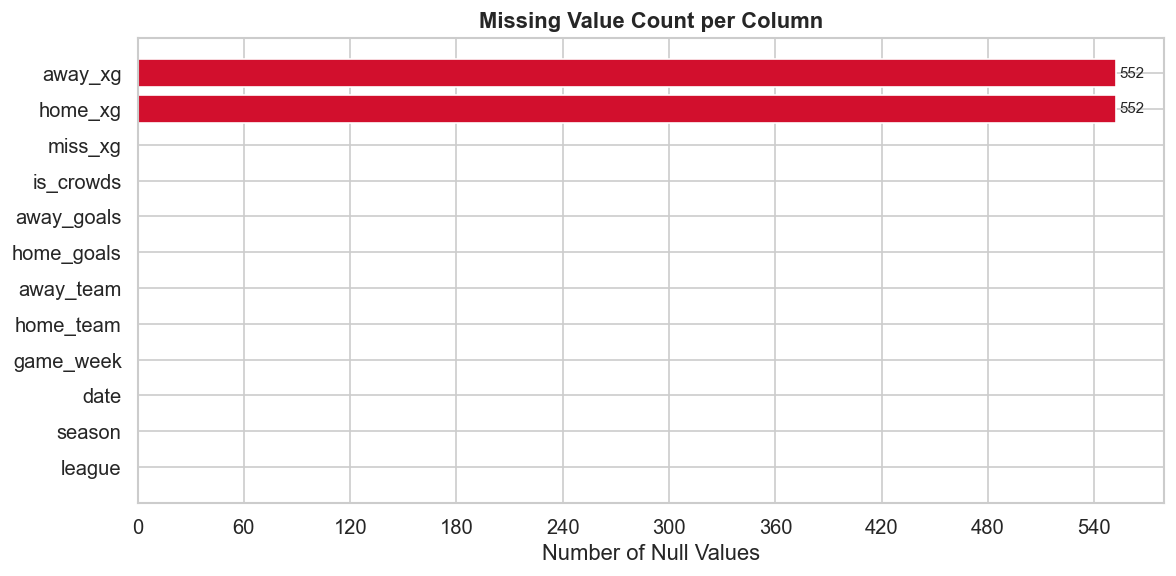

In [23]:
# Visualise null counts across all columns
all_nulls = df.isna().sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colours_bar = [COLOURS[0] if v == 0 else COLOURS[3] for v in all_nulls.values]
ax.barh(all_nulls.index, all_nulls.values, color=colours_bar)
ax.set_title('Missing Value Count per Column', fontweight='bold')
ax.set_xlabel('Number of Null Values')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# Annotate non-zero bars with count
for i, (val, col) in enumerate(zip(all_nulls.values, all_nulls.index)):
    if val > 0:
        ax.text(val + 2, i, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_PATH / 'missing_values_summary.png', bbox_inches='tight')
plt.show()

In [24]:
# Data type verification
print('Column dtypes:')
print(df.dtypes.to_string())

Column dtypes:
league                   str
season                   str
date          datetime64[us]
game_week              int64
home_team                str
away_team                str
home_goals             int64
away_goals             int64
home_xg              float64
away_xg              float64
is_crowds              int64
miss_xg                int64


In [25]:
# Category counts and final shape
print('Unique value counts:')
for col in ['league', 'season', 'home_team', 'away_team']:
    print(f'  {col}: {df[col].nunique()} unique values')

print(f'\nFinal dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Unique value counts:
  league: 3 unique values
  season: 8 unique values
  home_team: 87 unique values
  away_team: 87 unique values

Final dataset shape: 11,239 rows × 12 columns


## 12. Save Cleaned Dataset

Save the fully cleaned and validated dataset as `df_cleaned.csv`. This file is the canonical source for all subsequent feature engineering, train/test splitting, and modelling work — do not modify it further; apply any additional transformations in downstream notebooks.

In [26]:
save_path = OUT_PATH / 'df_cleaned.csv'
df.to_csv(save_path, index=False)

print(f'Saved: {save_path}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Saved: ../Outputs/Cleaning/df_cleaned.csv
Shape: 11,239 rows × 12 columns
